# H&M Personalized Fashion Recommendations

<img src='https://cloudfront-eu-central-1.images.arcpublishing.com/businessoffashion/XQS2445RMVACTAO7JLFEFFLCHE.jpg'>

Bu çalışmada H&M Personalized Fashion Recommendations yarışması için müşteri geçmişi, ürün sıklığı ve son dönem etkisini birlikte kullanan daha güçlü bir recommendation baseline oluşturulmuştur.

## Akış

1. Kütüphaneleri yükleme
2. Drive bağlama ve zip açma
3. Veri dosyalarını tanımlama
4. Ana tabloları inceleme
5. Transaction mantığını anlama
6. Gelişmiş recommendation yaklaşımı
7. Submission formatı
8. Sonuç

## 1. Kütüphaneleri Yükleme

In [1]:
# Bu bölümde veri analizi ve recommendation başlangıç akışı için gerekli kütüphaneleri içe aktarıyoruz.


In [2]:
from google.colab import drive
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 2. Drive Bağlama ve Zip Açma

In [3]:
# Bu bölümde Google Drive içindeki yarışma zip dosyasını Colab çalışma alanına açıyoruz.


In [4]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/h-and-m-personalized-fashion-recommendations.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config',
 'customers.csv',
 'images',
 'sample_submission.csv',
 'articles.csv',
 'drive',
 'transactions_train.csv',
 'sample_data']

## 3. Veri Dosyalarını Tanımlama

In [5]:
# Bu bölümde açılan dosyaların yollarını tanımlıyoruz.


In [6]:
search_roots = ['/content', '/content/drive/MyDrive/Colab Data Dosyaları']
data_path = None

for root in search_roots:
    for current_root, dirs, files in os.walk(root):
        if 'articles.csv' in files and 'customers.csv' in files and 'transactions_train.csv' in files:
            data_path = current_root
            break
    if data_path is not None:
        break

if data_path is None:
    raise FileNotFoundError('articles.csv, customers.csv ve transactions_train.csv ayni klasorde bulunamadi.')

articles_path = os.path.join(data_path, 'articles.csv')
customers_path = os.path.join(data_path, 'customers.csv')
transactions_path = os.path.join(data_path, 'transactions_train.csv')
sample_submission_path = os.path.join(data_path, 'sample_submission.csv')

print('Veri klasoru:', data_path)
print('Articles:', articles_path)
print('Customers:', customers_path)
print('Transactions:', transactions_path)


Veri klasoru: /content
Articles: /content/articles.csv
Customers: /content/customers.csv
Transactions: /content/transactions_train.csv


## 4. Ana Tabloları İnceleme

In [7]:
# Bu bölümde articles, customers ve transactions tablolarını açıp temel yapılarını inceliyoruz.


In [8]:
sample_transactions_rows = 500000
transaction_columns = ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

articles = pd.read_csv(articles_path)
customers = pd.read_csv(customers_path)
transactions = pd.read_csv(
    transactions_path,
    usecols=transaction_columns,
    nrows=sample_transactions_rows
)
sample_submission = pd.read_csv(sample_submission_path)

print('Articles shape:', articles.shape)
print('Customers shape:', customers.shape)
print('Transactions shape (sample):', transactions.shape)
print('Sample submission shape:', sample_submission.shape)


Articles shape: (105542, 25)
Customers shape: (1371980, 7)
Transactions shape (sample): (500000, 5)
Sample submission shape: (1371980, 2)


In [9]:
articles.head()


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [10]:
customers.head()


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [11]:
transactions.head()


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


## 5. Transaction Mantığını Anlama

In [12]:
# Bu bölümde müşterilerin hangi ürünleri ne sıklıkla aldığını inceleyerek recommendation mantığını kurmaya başlıyoruz.


In [13]:
top_articles = transactions['article_id'].value_counts().head(12)
top_articles


,count
article_id,
685687003,1241
685687002,1210
685687004,1201
685687001,1201
539723005,1111
399223001,878
562245001,812
573716012,782
692454002,769


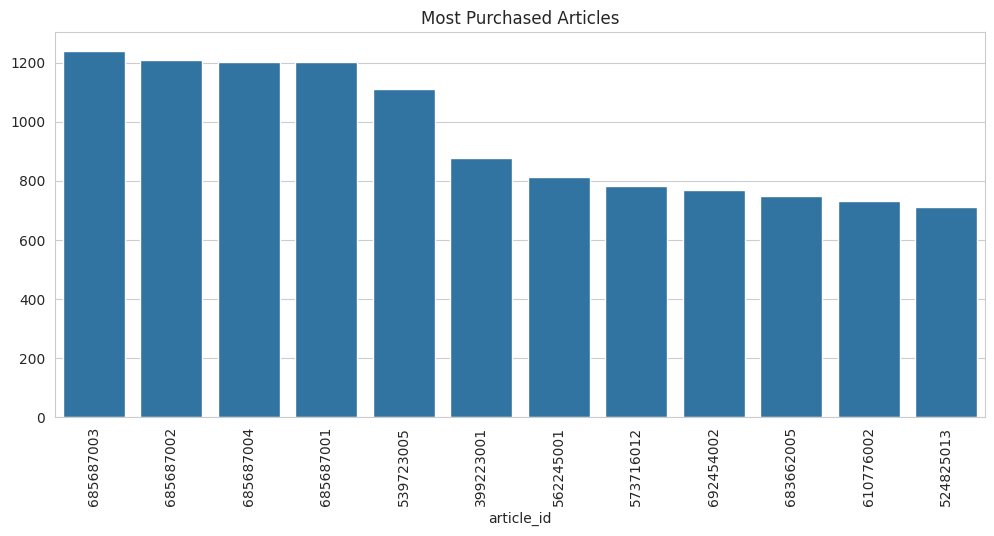

In [14]:
plt.figure(figsize=(12, 5))
sns.barplot(x=top_articles.index.astype(str), y=top_articles.values)
plt.title('Most Purchased Articles')
plt.xticks(rotation=90)
plt.show()


In [15]:
customer_purchase_counts = transactions['customer_id'].value_counts().head(10)
customer_purchase_counts


,count
customer_id,
75c54a755b8a467e53e0a4e01833deb029734feb22ad25438137925123a38f8b,169
2039c3a9cdd14183aae75ea2b5e52956e1b5d22b5ff4aa27da504c4f03ac8cd2,108
2fdf822dbaad2b983b37e651a982bba24352a92c8a5c4c75be25c771f2af6d13,103
a81e0b7657a090198d8138c95fae7db1218305b97bb8fd3f42b8d8e1b6d5b846,100
ef196ddee4c886fd11ec06fadbbc5e7d554c32a0d0bbaab239953bc22d07a4a5,88
c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27cf9bda5517c8774f8fa,86
fbb9a3f6db1c4d49fd7c9892c3290a09caa2ea36ac00c48296f889d2c12226f9,81
4aa23f5f3013303a7f194972fd68cf5cb04cdc88ab69bee8acf06283e7988e15,80
f6fbb1480291047c308f83a25e8e8b1e2c5a44a9390662b1d8435f700b5555db,80


## 6. Gelişmiş Recommendation Yaklaşımı

In [16]:
# Bu bölümde müşteri geçmişi, ürün sıklığı ve son dönem etkisini birlikte kullanan daha güçlü bir recommendation baseline kuruyoruz.


In [17]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['article_id'] = transactions['article_id'].astype(str)

latest_date = transactions['t_dat'].max()
transactions['days_from_last'] = (latest_date - transactions['t_dat']).dt.days
transactions['recency_weight'] = 1 / (1 + transactions['days_from_last'])

customer_article_stats = (
    transactions.groupby(['customer_id', 'article_id'])
    .agg(
        purchase_count=('article_id', 'size'),
        mean_recency_weight=('recency_weight', 'mean'),
        last_purchase=('t_dat', 'max')
    )
    .reset_index()
)

customer_article_stats['score'] = (
    customer_article_stats['purchase_count'] * 0.7 +
    customer_article_stats['mean_recency_weight'] * 10 * 0.3
)

customer_article_stats = customer_article_stats.sort_values(
    ['customer_id', 'score', 'last_purchase'], ascending=[True, False, False]
)

customer_top_articles = (
    customer_article_stats.groupby('customer_id')['article_id']
    .apply(lambda x: list(dict.fromkeys(x))[:12])
)

global_top_articles = transactions['article_id'].value_counts().head(12).index.tolist()

def build_prediction(customer_id):
    items = customer_top_articles.get(customer_id, [])
    if len(items) < 12:
        needed = 12 - len(items)
        fillers = [item for item in global_top_articles if item not in items][:needed]
        items = items + fillers
    return ' '.join(items[:12])

sample_submission['prediction'] = sample_submission['customer_id'].apply(build_prediction)
sample_submission.head()


,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,685687003 685687002 685687004 685687001 539723...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,666448006 583558001 673677002 521269001 639677...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001 541518023 685687003 685687002 685687...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,685687003 685687002 685687004 685687001 539723...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,685687003 685687002 685687004 685687001 539723...


## 7. Submission Formatı

In [18]:
# Bu bölümde yarışmanın istediği submission formatını hazırlıyoruz.


In [19]:
submission = sample_submission.copy()
submission.to_csv('hm_recommendation_submission.csv', index=False)
submission.head()


,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,685687003 685687002 685687004 685687001 539723...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,666448006 583558001 673677002 521269001 639677...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001 541518023 685687003 685687002 685687...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,685687003 685687002 685687004 685687001 539723...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,685687003 685687002 685687004 685687001 539723...


## 8. Sonuç

Bu çalışmada H&M Personalized Fashion Recommendations yarışması için müşteri geçmişi, ürün sıklığı ve son dönem etkisini birlikte kullanan bir model oluşturuldu. Bazlı ürün tercihleri skorlanarak öneri listesi üretildi ve eksik kalan kısımlar en popüler ürünlerle tamamlandı.